This notebook creates the Italy-only mask to apply to the CERRA dataset. Once the mask is created, it can be applied directly to the dataset using cdo 

In [8]:
from pathlib import Path
import numpy as np
import shapely
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

## 1. Load Italy boundary

In [9]:
italy_file = Path(r"C:\Users\ludog\Desktop\WORK\paper fontanelle\data\Italy_boundary.gpkg")

italy = gpd.read_file(italy_file)
italy = italy.to_crs("EPSG:4326")

italy_geometry = italy.geometry.union_all()
if not shapely.is_valid(italy_geometry):
    italy_geometry = shapely.make_valid(italy_geometry)

print(italy.crs)
print(italy_geometry.bounds)  # sanity check: should be roughly (6.6, 35.5, 18.5, 47.1)

EPSG:4326
(6.63005092800006, 35.492575603000034, 18.515976386000034, 47.091723400000035)


## 2. Open CERRA

cfgrib/xarray already avoids loading the full array on `open_dataset` - it only reads
data when something actually triggers it (`.values`, `.compute()`, `.to_netcdf()`, etc.).
So as long as we crop to Italy's bounding box *before* any of those triggers, we never
touch the full-grid array. No dask required for this.

In [10]:
cerra_file = Path(r"C:\Users\ludog\Desktop\WORK\paper fontanelle\data\cerra_2mt_2025.grib")

ds = xr.open_dataset(
    cerra_file,
    engine="cfgrib",
    backend_kwargs={"indexpath": ""},
    # No `chunks=` here: that needs dask installed. cfgrib/xarray already
    # reads GRIB lazily by default - it won't pull data into memory until
    # something actually triggers a read (e.g. .values, .compute(), .to_netcdf()).
    # Combined with the bbox crop below, that's enough to avoid loading the
    # full 13 GB. If you DO want dask (parallel reads, progress bars, etc.),
    # install it with: pip install dask   (or: conda install -c conda-forge dask)
    # and then you can add chunks={"time": 100} back in.
)

lon = ds["longitude"].values   # coordinate arrays are small (1069x1069), fine to load eagerly
lat = ds["latitude"].values

print(ds)

<xarray.Dataset> Size: 13GB
Dimensions:            (time: 2920, y: 1069, x: 1069)
Coordinates:
  * time               (time) datetime64[ns] 23kB 2025-01-01 ... 2025-12-31T2...
    valid_time         (time) datetime64[ns] 23kB ...
    latitude           (y, x) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude          (y, x) float64 9MB 342.5 342.6 342.6 ... 74.04 74.11
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (time, y, x) float32 13GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-08-02T14:48 GRIB to CDM+CF via cfgrib-0.9.1...


## 3. Build the mask

In [11]:
points = shapely.points(lon.ravel(), lat.ravel())
inside = shapely.covers(italy_geometry, points).reshape(lon.shape)

italy_mask = xr.DataArray(
    inside,
    dims=("y", "x"),
    coords={
        "latitude": (("y", "x"), lat),
        "longitude": (("y", "x"), lon),
    },
    name="italy_mask",
)

n_cells = int(italy_mask.sum())
expected = 301_340 / (5.5 * 5.5)  # Italy's land area / cell area, rough sanity check
print(f"Cells inside Italy: {n_cells}  (rough expectation: ~{expected:.0f})")

Cells inside Italy: 10127  (rough expectation: ~9962)


## 4. Verify the mask properly

`pcolormesh` on raw curvilinear lon/lat arrays needs *locally* monotonic coordinates
to compute cell edges correctly - on an LCC grid that assumption breaks down, which is
exactly the warning you saw, and it can make a perfectly correct mask look wrong or
smeared. A plain scatter of the selected points sidesteps that entirely and is a much
more trustworthy sanity check.

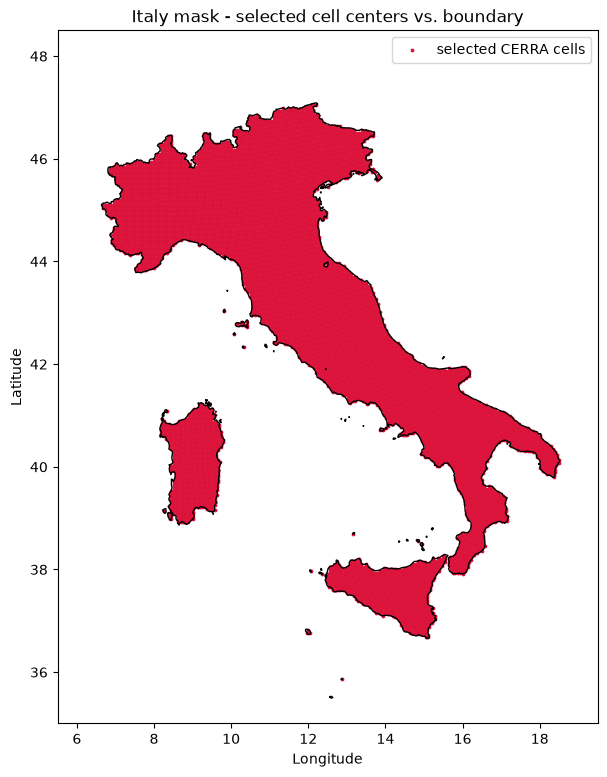

In [12]:
fig, ax = plt.subplots(figsize=(7, 9))

ax.scatter(lon[inside], lat[inside], s=3, color="crimson", label="selected CERRA cells")
italy.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_xlim(5.5, 19.5)
ax.set_ylim(35, 48.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Italy mask - selected cell centers vs. boundary")
ax.legend()
plt.show()

## 5. Export the mask and apply it with CDO



In [13]:
import xarray as xr

# Export the mask as its own tiny NetCDF (no time dimension - this is ~1 MB, not 13 GB)
mask_ds = xr.Dataset(
    {"italy_mask": (("y", "x"), inside.astype("int8"))},
    coords={
        "latitude": (("y", "x"), lat),
        "longitude": (("y", "x"), lon),
    },
)
mask_ds["italy_mask"].attrs = {"long_name": "1 = inside Italy, 0 = outside"}

mask_path = Path(r"C:\Users\ludog\Desktop\WORK\paper fontanelle\data\italy_mask.nc")
mask_ds.to_netcdf(mask_path)
print("Saved mask to:", mask_path)

# Bounding box indices, converted to CDO's convention:
# - selindexbox is 1-based and inclusive (Python's np.where()/slicing is 0-based)
ys, xs = np.where(inside)
x1, x2 = int(xs.min()) + 1, int(xs.max()) + 1
y1, y2 = int(ys.min()) + 1, int(ys.max()) + 1
print(f"CDO bounding box indices -> x: {x1},{x2}   y: {y1},{y2}")

Saved mask to: C:\Users\ludog\Desktop\WORK\paper fontanelle\data\italy_mask.nc
CDO bounding box indices -> x: 516,699   y: 249,477


### Run this part in a terminal, with CDO installed

Replace `x1,x2,y1,y2` with the numbers printed above. This does two things per file:
1. `selindexbox` crops to Italy's bounding box first - cheap, purely index-based, so it
   works fine on the LCC grid (unlike `sellonlatbox`, which needs a regular lat/lon grid).
2. `ifthen` applies the mask, setting cells outside Italy to missing. The mask has no
   time dimension, so CDO automatically broadcasts it across all timesteps.

```bash
# Also crop the mask itself to the same bounding box, once:
cdo -O selindexbox,x1,x2,y1,y2 italy_mask.nc italy_mask_bbox.nc

cdo -O selindexbox,516,699,249,477 italy_mask.nc italy_mask_bbox.nc

# Then, for CERRA t2m 2025 (or any other file on the same grid):
cdo -O ifthen italy_mask_bbox.nc -selindexbox,516,699,249,477 cerra_2mt_2025.grib cerra_2mt_2025_italy.nc
```

For a future dataset on the same grid (e.g. a different variable or year), you only
need to re-run the second command with a new input filename - `italy_mask_bbox.nc`
stays the same, and you never have to touch Python or the full grid again.

If your CDO build doesn't like reading GRIB with `-O` chaining, split it into two
steps instead:
```bash
cdo -O selindexbox,x1,x2,y1,y2 -sorttimestamp cerra_2mt_2025.grib cerra_2mt_2025_bbox.nc
cdo -O ifthen italy_mask_bbox.nc cerra_2mt_2025_bbox.nc cerra_2mt_2025_italy.nc
```